In [ ]:
picture = got.read_camera_data()
ok,picture_jpg = cv2.imencode(".jpg",picture)
display(Image(picture_jpg.tobytes()))
picture=np.frombuffer(picture,np.uint8)
got.open_camera()
picture =cv2.imdecode(picture,cv2.IMREAD_COLOR)

In [3]:
import numpy as np
import cv2
from IPython.display import Image, display, clear_output

from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.236")

192.168.1.236:50051


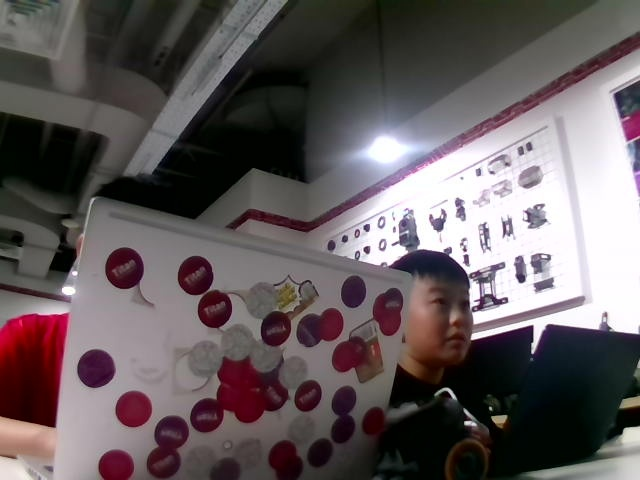

In [ ]:
got.open_camera()
picture = got.read_camera_data()
picture = np.frombuffer(picture, np.uint8)
picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
ok,picture_jpg = cv2.imencode(".jpg", picture)
display(Image(picture_jpg.tobytes()))

Photos to video

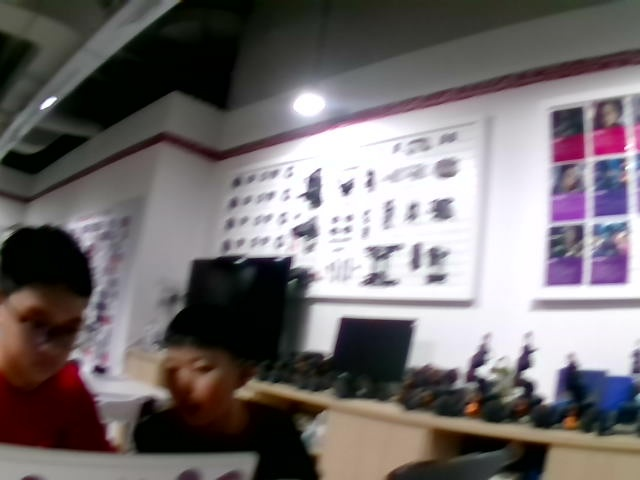

In [5]:
got.open_camera()

for i in range(100): # colon

    picture = got.read_camera_data()
    picture = np.frombuffer(picture, np.uint8)
    picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
    ok,picture_jpg = cv2.imencode(".jpg", picture)
    display(Image(picture_jpg.tobytes()))
    # clear the previous image
    clear_output(True)

In [7]:
laser1 = got.read_distance_data(21)
laser2 = got.read_distance_data(51)

print(laser1, laser2)

-1 250.0


Motion detection robot

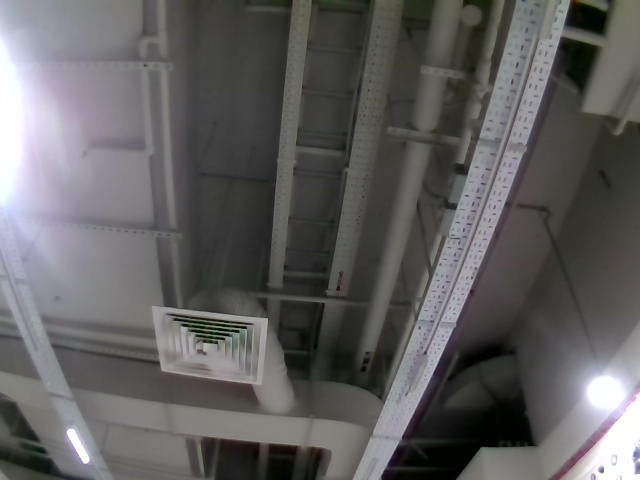

In [ ]:
import time

got.open_camera()

while True:
    laser = got.read_distance_data(51)
    picture = got.read_camera_data()

    if laser > 30:
        got.show_light_rgb_effect(255, 0, 255, 3)
        time.sleep(0.1)
    else:
        if picture is None:
            print("No data found.")
            continue
        picture = np.frombuffer(picture, np.uint8)
        picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
        ok,picture_jpg = cv2.imencode(".jpg", picture)
        display(Image(picture_jpg.tobytes()))
        # show red light for 2 seconds after taking picture
        got.show_light_rgb_effect(255, 0, 0, 3)
        got.play_sound("monkey")
        time.sleep(2)
        got.turn_off_lights()
        break

got.play_audio_tts("gotcha, ha ha", 0, False)

Spin robotic guard

In [ ]:
import time

got.open_camera()
got.balance_start_balancing()
time.sleep(2)

while True:
    laser = got.read_distance_data(51)
    picture = got.read_camera_data()

    if laser > 30:
        got.balance_turn_speed(3, 10)
        got.show_light_rgb_effect(255, 0, 255, 3)
        time.sleep(0.1)
    else:
        got.balance_stop_balancing()
        if picture is None:
            print("No data found.")
            continue
        picture = np.frombuffer(picture, np.uint8)
        picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
        ok,picture_jpg = cv2.imencode(".jpg", picture)
        display(Image(picture_jpg.tobytes()))
        # show red light for 2 seconds after taking picture
        got.show_light_rgb_effect(255, 0, 0, 3)
        got.play_sound("monkey")
        time.sleep(2)
        got.turn_off_lights()
        break

got.play_audio_tts("gotcha, ha ha", 0, False)